## Байесовская классификация

В работе выполняется классификация набора данных Iris с использованием алгоритма Gaussian Naive Bayes.  
Проводится серия экспериментов с изменением доли обучающей выборки от 60% до 90% с шагом 5%.  
Вычисляются метрики: Accuracy, Precision, Recall, F1-score.  
Результаты визуализируются на общем графике.


In [15]:
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [16]:
# Загрузка набора данных
data = load_iris()
X = data.data
y = data.target

In [17]:
train_sizes = np.arange(0.6, 0.95, 0.05)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for train_size in train_sizes:
    # Разделяем данные на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_size, random_state=42, stratify=y
    )

    # Создаём и обучаем модель
    model = GaussianNB()
    model.fit(X_train, y_train)

    # Получаем предсказания
    y_pred = model.predict(X_test)

    # Вычисляем метрики
    accuracy_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred, average='macro'))
    recall_list.append(recall_score(y_test, y_pred, average='macro'))
    f1_list.append(f1_score(y_test, y_pred, average='macro'))



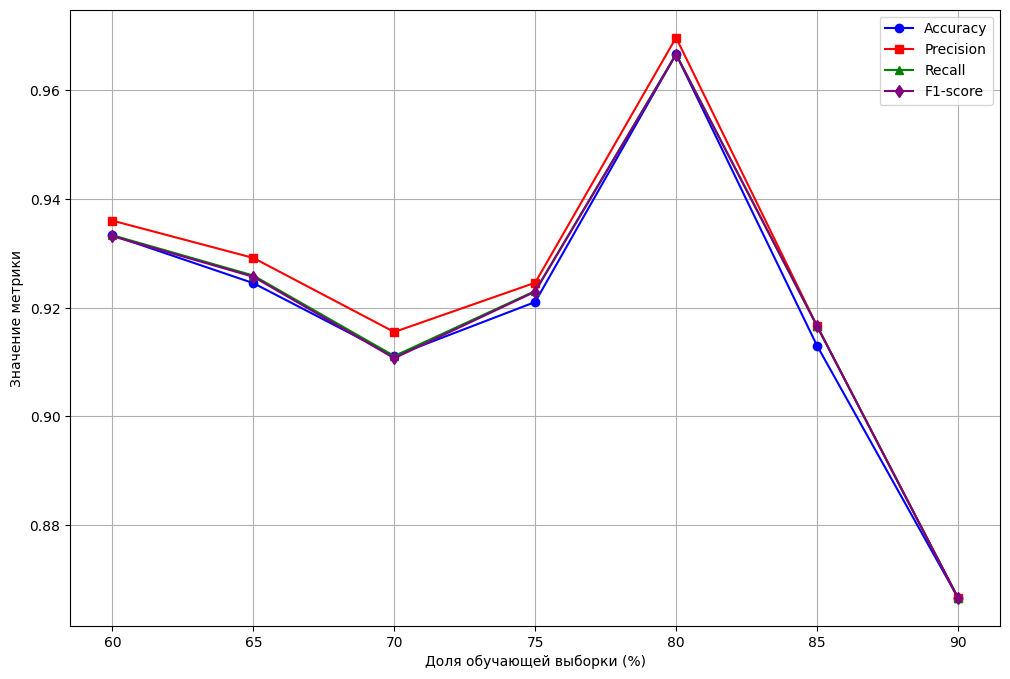

In [18]:
# Визуализация результатов
plt.figure(figsize=(12,8))

plt.plot(train_sizes * 100, accuracy_list, marker='o', label='Accuracy', color='blue')
plt.plot(train_sizes * 100, precision_list, marker='s', label='Precision', color='red')
plt.plot(train_sizes * 100, recall_list, marker='^', label='Recall', color='green')
plt.plot(train_sizes * 100, f1_list, marker='d', label='F1-score', color='purple')

plt.xlabel("Доля обучающей выборки (%)")
plt.ylabel("Значение метрики")
plt.legend()
plt.grid(True)

plt.show()